# Section 5.1 Single-cell time-course main suite

This notebook reproduces the Section 5.1 EB time-course main suite as a tutorial. The aim is not only to regenerate the tables and Figure 5.1, but to show how the experiment is assembled: which time points are observed, which point is hidden, how local and shared bridges differ, and how endpoint metrics connect to the paper-facing claim table.


## 1. What this experiment tests

The EB data contain single-cell snapshots at five ordered time points. We train flow-matching bridges from the initial snapshot and ask two complementary questions:

- Can a model recover the hidden intermediate population at `t2`?
- Can a model roll out to the seen endpoint `t4` without accumulating too much long-horizon error?
- Are velocities smooth across hand-off points where pairwise local bridges switch from one local model to the next?

The comparison is deliberately small: pairwise local bridges, one shared adjacent-only field, and two shared fields that also see skip pairs.


## 2. Setup and reproducibility controls

The setup cell keeps only environment and import mechanics. Reusable path, IO, display, plotting, and audit helpers live in `src.ch05_section51_tutorial`; the experimental steps below remain visible in this notebook.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch05_section51")

from pathlib import Path
import sys

candidate_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path("/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology"),
    Path("/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology"),
]
PROJECT_ROOT = next(
    candidate for candidate in candidate_roots
    if (candidate / "src" / "ch05_experiments.py").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: /import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology


In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.ch05_experiments import (
    _global_rollout,
    _local_sequence_rollout,
    _train_global_bridge_model,
    _train_local_bridge,
    build_ch05_section51_main_text_results,
    endpoint_distribution_metrics,
    load_eb_ch05,
    set_global_seed,
    summarize_eb_section51_main_suite,
)
from src.ch05_section51_tutorial import (
    audit_section51_main_text_results,
    display_png,
    json_ready,
    make_section51_config,
    preview_frame,
    verify_expected_display_values,
    write_section51_artifacts,
)


In [3]:
CONFIG = make_section51_config(PROJECT_ROOT)
FIG_DIR = CONFIG.fig_dir
TABLE_DIR = CONFIG.table_dir
OUTPUT_DIR = CONFIG.output_dir
DEFAULT_SEED = CONFIG.default_seed
SECTION51_MAIN_SUITE_SEEDS = CONFIG.suite_seeds
BATCH_SIZE = CONFIG.batch_size
NFE = CONFIG.nfe
EB_MAX_CELLS_PER_TIME = CONFIG.eb_max_cells_per_time
DEVICE = CONFIG.device

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

set_global_seed(DEFAULT_SEED)
print(f"Device: {DEVICE}; batch={BATCH_SIZE}; nfe={NFE}")
print(f"Seeds: {SECTION51_MAIN_SUITE_SEEDS}")
print(f"EB max cells per time: {EB_MAX_CELLS_PER_TIME}")


Device: cuda; batch=256; nfe=32
Seeds: [42, 43, 44]
EB max cells per time: 900


## 3. Load EB data

The loader standardizes the PC representation, keeps a balanced maximum number of cells per time point, and returns dictionaries keyed by the original time labels. We keep `t2` hidden for interpolation-style evaluation and use `t4` as a long-horizon endpoint check.


In [4]:
eb = load_eb_ch05(
    CONFIG.eb_path,
    max_cells_per_time=EB_MAX_CELLS_PER_TIME,
    seed=DEFAULT_SEED,
    n_pc=20,
)

by_time = eb["by_time"]
time_values = eb["time_values"]
print(f"EB path: {CONFIG.eb_path.relative_to(PROJECT_ROOT)}")
print("Time values:", time_values)
preview_frame(eb["counts"], n=10)


EB path: data/trajectorynet_eb/eb_velocity_v5.npz
Time values: {'0': 0.0, '1': 0.25, '2': 0.5, '3': 0.75, '4': 1.0}


,time,n_cells
0,0,900
1,1,900
2,2,900
3,3,900
4,4,900


,time,n_cells
0,0,900
1,1,900
2,2,900
3,3,900
4,4,900


## 4. Define pair topology and model variants

The topology is the experimental design. Pairwise local bridges train one model per adjacent interval. Shared models train one global velocity field over several source-target pairs. Skip supervision adds longer pairs so the field sees nonlocal constraints, but the weighting controls whether skip pairs dominate the adjacent pairs.


In [5]:
adjacent_pairs = [("0", "1"), ("1", "3"), ("3", "4")]
skip_pairs = adjacent_pairs + [("0", "3"), ("1", "4"), ("0", "4")]

shared_specs = [
    {
        "variant": "shared_adjacent_only_6000",
        "variant_family": "shared_adjacent",
        "pairs": adjacent_pairs,
        "training_steps_total": 6000,
        "sampling": "uniform_adjacent",
        "pair_weights": None,
        "seed_offset": 30,
    },
    {
        "variant": "shared_skip_uniform_6000",
        "variant_family": "shared_skip",
        "pairs": skip_pairs,
        "training_steps_total": 6000,
        "sampling": "uniform_adjacent_skip",
        "pair_weights": None,
        "seed_offset": 40,
    },
    {
        "variant": "shared_skip_adj2_skip1_9000",
        "variant_family": "shared_skip",
        "pairs": skip_pairs,
        "training_steps_total": 9000,
        "sampling": "adjacent_total_2_3_skip_total_1_3",
        "pair_weights": [2.0, 2.0, 2.0, 1.0, 1.0, 1.0],
        "seed_offset": 50,
    },
]

print("Adjacent pairs:", adjacent_pairs)
print("Skip pairs:", skip_pairs)


Adjacent pairs: [('0', '1'), ('1', '3'), ('3', '4')]
Skip pairs: [('0', '1'), ('1', '3'), ('3', '4'), ('0', '3'), ('1', '4'), ('0', '4')]


In [6]:
variant_table = pd.DataFrame([
    {
        "variant": "pairwise_local_bridges_6000",
        "family": "pairwise",
        "pairs": ";".join(f"{a}-{b}" for a, b in adjacent_pairs),
        "steps": 6000,
        "sampling": "local_pairwise",
    },
    *[
        {
            "variant": spec["variant"],
            "family": spec["variant_family"],
            "pairs": ";".join(f"{a}-{b}" for a, b in spec["pairs"]),
            "steps": spec["training_steps_total"],
            "sampling": spec["sampling"],
        }
        for spec in shared_specs
    ],
])
preview_frame(variant_table, n=10)


,variant,family,pairs,steps,sampling
0,pairwise_local_bridges_6000,pairwise,0-1;1-3;3-4,6000,local_pairwise
1,shared_adjacent_only_6000,shared_adjacent,0-1;1-3;3-4,6000,uniform_adjacent
2,shared_skip_uniform_6000,shared_skip,0-1;1-3;3-4;0-3;1-4;0-4,6000,uniform_adjacent_skip
3,shared_skip_adj2_skip1_9000,shared_skip,0-1;1-3;3-4;0-3;1-4;0-4,9000,adjacent_total_2_3_skip_total_1_3


,variant,family,pairs,steps,sampling
0,pairwise_local_bridges_6000,pairwise,0-1;1-3;3-4,6000,local_pairwise
1,shared_adjacent_only_6000,shared_adjacent,0-1;1-3;3-4,6000,uniform_adjacent
2,shared_skip_uniform_6000,shared_skip,0-1;1-3;3-4;0-3;1-4;0-4,6000,uniform_adjacent_skip
3,shared_skip_adj2_skip1_9000,shared_skip,0-1;1-3;3-4;0-3;1-4;0-4,9000,adjacent_total_2_3_skip_total_1_3


## 5. Train pairwise local bridges

A pairwise baseline trains one independent bridge per adjacent interval. This is easy to interpret, but its velocity field is not globally shared, so rollouts must stitch local bridges together at hand-off times.


In [7]:
pair_steps = 6000 // len(adjacent_pairs)
pair_models_by_seed = {}
rng_state_after_pairwise_by_seed = {}
histories = {}

for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    set_global_seed(DEFAULT_SEED)
    pair_models = {}
    for pair_idx, pair in enumerate(adjacent_pairs):
        model, hist = _train_local_bridge(
            by_time[pair[0]],
            by_time[pair[1]],
            pair_steps,
            BATCH_SIZE,
            int(run_seed) + 10 + pair_idx,
            device=DEVICE,
        )
        pair_models[pair] = model
        histories[(int(run_seed), f"pairwise_{pair[0]}_{pair[1]}")] = hist
    pair_models_by_seed[int(run_seed)] = pair_models
    rng_state_after_pairwise_by_seed[int(run_seed)] = {
        "cpu": torch.random.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }

print(f"Trained {len(pair_models_by_seed) * len(adjacent_pairs)} local bridges")
print("Pairwise steps per local bridge:", pair_steps)


Trained 9 local bridges
Pairwise steps per local bridge: 2000


## 6. Train shared global bridges

The shared models use one velocity field across multiple source-target pairs. The adjacent-only shared model tests whether global sharing helps recover a hidden intermediate snapshot. The skip variants test whether long-range pair supervision helps endpoint rollout.


In [8]:
shared_models_by_seed = {}

for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    torch.random.set_rng_state(rng_state_after_pairwise_by_seed[run_seed]["cpu"])
    cuda_state = rng_state_after_pairwise_by_seed[run_seed]["cuda"]
    if cuda_state is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(cuda_state)

    shared_models = {}
    for spec in shared_specs:
        model, hist = _train_global_bridge_model(
            by_time,
            spec["pairs"],
            time_values,
            int(spec["training_steps_total"]),
            BATCH_SIZE,
            run_seed + int(spec["seed_offset"]),
            device=DEVICE,
            pair_weights=spec["pair_weights"],
        )
        shared_models[spec["variant"]] = model
        histories[(run_seed, spec["variant"])] = hist
    shared_models_by_seed[run_seed] = shared_models

print(f"Trained {len(shared_models_by_seed) * len(shared_specs)} shared models")
print("Stored history keys:", len(histories))


Trained 9 shared models
Stored history keys: 18


## 7. Roll out predictions

Every variant starts from the observed `t0` population. We evaluate two endpoints: hidden `t2` at global time `0.50`, and seen `t4` at global time `1.00`. Pairwise rollouts stitch local bridges; shared rollouts integrate one global field.


In [9]:
X0 = by_time["0"]
targets = {"hidden_t2": by_time["2"], "seen_t4": by_time["4"]}
predictions_by_seed = {}
print("Evaluation targets:", sorted(targets.keys()))


Evaluation targets: ['hidden_t2', 'seen_t4']


In [10]:
for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    pair_models = pair_models_by_seed[run_seed]
    predictions_by_seed[run_seed] = {
        "pairwise_local_bridges_6000": {
            "variant_family": "pairwise",
            "training_steps_total": int(pair_steps * len(adjacent_pairs)),
            "sampling": "local_pairwise",
            "pairs": adjacent_pairs,
            "pair_weights": "",
            "hidden_t2": _local_sequence_rollout(
                pair_models,
                X0,
                [(("0", "1"), 1.0), (("1", "3"), 0.5)],
                NFE,
                device=DEVICE,
            ),
            "seen_t4": _local_sequence_rollout(
                pair_models,
                X0,
                [(("0", "1"), 1.0), (("1", "3"), 1.0), (("3", "4"), 1.0)],
                NFE,
                device=DEVICE,
            ),
        }
    }

print("Pairwise predictions complete:", len(predictions_by_seed))


Pairwise predictions complete: 3


In [11]:
for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    for spec in shared_specs:
        model = shared_models_by_seed[run_seed][spec["variant"]]
        weights = spec["pair_weights"]
        pair_weights = "uniform" if weights is None else ",".join(
            f"{w:.6g}" for w in (np.asarray(weights, dtype=float) / np.sum(weights))
        )
        predictions_by_seed[run_seed][spec["variant"]] = {
            "variant_family": spec["variant_family"],
            "training_steps_total": int(spec["training_steps_total"]),
            "sampling": spec["sampling"],
            "pairs": spec["pairs"],
            "pair_weights": pair_weights,
            "hidden_t2": _global_rollout(model, X0, 0.5, NFE * 2, device=DEVICE),
            "seen_t4": _global_rollout(model, X0, 1.0, NFE * 4, device=DEVICE),
        }

print("Prediction variants:", sorted(next(iter(predictions_by_seed.values())).keys()))


Prediction variants: ['pairwise_local_bridges_6000', 'shared_adjacent_only_6000', 'shared_skip_adj2_skip1_9000', 'shared_skip_uniform_6000']


## 8. Compute endpoint metrics

The endpoint table is one row per seed, variant, and target. Lower MMD, sliced Wasserstein, and centroid distance all indicate closer agreement between a rollout population and the held-out or endpoint snapshot.


In [12]:
rows = []
for run_seed, predictions in predictions_by_seed.items():
    for variant, payload in predictions.items():
        for target_name in ["hidden_t2", "seen_t4"]:
            metrics = endpoint_distribution_metrics(payload[target_name], targets[target_name])
            rows.append(
                {
                    "experiment": "EB Section 5.1 main suite",
                    "seed": int(run_seed),
                    "variant": variant,
                    "variant_family": payload["variant_family"],
                    "target": target_name,
                    "training_steps_total": int(payload["training_steps_total"]),
                    "sampling": payload["sampling"],
                    "pairs": ";".join(f"{a}-{b}" for a, b in payload["pairs"]),
                    "pair_weights": payload["pair_weights"],
                    "mmd_rbf": float(metrics["mmd_rbf"]),
                    "sliced_w2": float(metrics["sliced_w2"]),
                    "centroid_l2": float(metrics["centroid_l2"]),
                }
            )

section51_metrics = pd.DataFrame(rows)
print("Metrics shape:", section51_metrics.shape)
preview_frame(
    section51_metrics,
    columns=["seed", "variant", "target", "mmd_rbf", "sliced_w2", "centroid_l2"],
    n=8,
)


Metrics shape: (24, 12)


,seed,variant,target,mmd_rbf,sliced_w2,centroid_l2
0,42,pairwise_local_bridges_6000,hidden_t2,0.080739,0.402712,1.115311
1,42,pairwise_local_bridges_6000,seen_t4,0.007199,0.214815,0.678975
2,42,shared_adjacent_only_6000,hidden_t2,0.059406,0.376872,1.157763
3,42,shared_adjacent_only_6000,seen_t4,0.008241,0.188741,0.571823
4,42,shared_skip_uniform_6000,hidden_t2,0.066241,0.383317,1.223948
5,42,shared_skip_uniform_6000,seen_t4,0.007472,0.205588,0.663954
6,42,shared_skip_adj2_skip1_9000,hidden_t2,0.063294,0.379612,1.318760
7,42,shared_skip_adj2_skip1_9000,seen_t4,0.008890,0.240141,0.767858


,seed,variant,target,mmd_rbf,sliced_w2,centroid_l2
0,42,pairwise_local_bridges_6000,hidden_t2,0.080739,0.402712,1.115311
1,42,pairwise_local_bridges_6000,seen_t4,0.007199,0.214815,0.678975
2,42,shared_adjacent_only_6000,hidden_t2,0.059406,0.376872,1.157763
3,42,shared_adjacent_only_6000,seen_t4,0.008241,0.188741,0.571823
4,42,shared_skip_uniform_6000,hidden_t2,0.066241,0.383317,1.223948
5,42,shared_skip_uniform_6000,seen_t4,0.007472,0.205588,0.663954
6,42,shared_skip_adj2_skip1_9000,hidden_t2,0.063294,0.379612,1.318760
7,42,shared_skip_adj2_skip1_9000,seen_t4,0.008890,0.240141,0.767858


## 9. Compute hand-off diagnostics

Endpoint scores do not tell us whether the learned velocity field is smooth at the observed hand-off points. The diagnostic below compares the velocity just before and after `t1` and `t3`. Pairwise local bridges can jump because the left and right sides are different models.


In [13]:
diag_rows = []
boundary_specs = [("t1", "1", 0.25), ("t3", "3", 0.75)]
device_obj = torch.device(DEVICE)

for run_seed in SECTION51_MAIN_SUITE_SEEDS:
    run_seed = int(run_seed)
    pair_models = pair_models_by_seed[run_seed]
    shared_models = shared_models_by_seed[run_seed]
    for boundary, boundary_time, t_global in boundary_specs:
        Xb = by_time[boundary_time]
        xb = torch.as_tensor(Xb, dtype=torch.float32, device=device_obj)
        left_pair = ("0", "1") if boundary == "t1" else ("1", "3")
        right_pair = ("1", "3") if boundary == "t1" else ("3", "4")
        with torch.no_grad():
            v_left = pair_models[left_pair](
                xb,
                torch.ones((len(Xb), 1), device=device_obj),
            ).detach().cpu().numpy()
            v_right = pair_models[right_pair](
                xb,
                torch.zeros((len(Xb), 1), device=device_obj),
            ).detach().cpu().numpy()
        diag_rows.append(
            {
                "experiment": "EB Section 5.1 main suite",
                "seed": int(run_seed),
                "variant": "pairwise_local_bridges_6000",
                "variant_family": "pairwise",
                "boundary": boundary,
                "training_steps_total": int(pair_steps * len(adjacent_pairs)),
                "sampling": "local_pairwise",
                "velocity_jump_mean_l2": float(np.linalg.norm(v_left - v_right, axis=1).mean()),
            }
        )
        for spec in shared_specs:
            model = shared_models[spec["variant"]]
            with torch.no_grad():
                t_left = torch.full((len(Xb), 1), max(0.0, t_global - 0.01), device=device_obj)
                t_right = torch.full((len(Xb), 1), min(1.0, t_global + 0.01), device=device_obj)
                vl = model(xb, t_left).detach().cpu().numpy()
                vr = model(xb, t_right).detach().cpu().numpy()
            diag_rows.append(
                {
                    "experiment": "EB Section 5.1 main suite",
                    "seed": int(run_seed),
                    "variant": spec["variant"],
                    "variant_family": spec["variant_family"],
                    "boundary": boundary,
                    "training_steps_total": int(spec["training_steps_total"]),
                    "sampling": spec["sampling"],
                    "velocity_jump_mean_l2": float(np.linalg.norm(vl - vr, axis=1).mean()),
                }
            )

section51_diag = pd.DataFrame(diag_rows)
print("Diagnostics shape:", section51_diag.shape)
preview_frame(section51_diag, columns=["seed", "variant", "boundary", "velocity_jump_mean_l2"], n=8)


Diagnostics shape: (24, 8)


,seed,variant,boundary,velocity_jump_mean_l2
0,42,pairwise_local_bridges_6000,t1,8.053829
1,42,shared_adjacent_only_6000,t1,8.168668
2,42,shared_skip_uniform_6000,t1,5.628531
3,42,shared_skip_adj2_skip1_9000,t1,8.994892
4,42,pairwise_local_bridges_6000,t3,8.590636
5,42,shared_adjacent_only_6000,t3,4.799017
6,42,shared_skip_uniform_6000,t3,2.404037
7,42,shared_skip_adj2_skip1_9000,t3,4.212293


,seed,variant,boundary,velocity_jump_mean_l2
0,42,pairwise_local_bridges_6000,t1,8.053829
1,42,shared_adjacent_only_6000,t1,8.168668
2,42,shared_skip_uniform_6000,t1,5.628531
3,42,shared_skip_adj2_skip1_9000,t1,8.994892
4,42,pairwise_local_bridges_6000,t3,8.590636
5,42,shared_adjacent_only_6000,t3,4.799017
6,42,shared_skip_uniform_6000,t3,2.404037
7,42,shared_skip_adj2_skip1_9000,t3,4.212293


## 10. Summarize metrics into paper-facing tables

The raw tables keep seed-level rows. The summary tables average over seeds, and `build_ch05_section51_main_text_results` extracts only the values used by the paper text and claim audit.


In [14]:
section51_summary, section51_diag_summary = summarize_eb_section51_main_suite(
    section51_metrics,
    section51_diag,
)
section51_main_text_results, section51_summary_payload = build_ch05_section51_main_text_results(
    section51_summary,
    section51_diag_summary,
)

print("Summary shape:", section51_summary.shape)
print("Diagnostic summary shape:", section51_diag_summary.shape)
print("Main-text result shape:", section51_main_text_results.shape)
preview_frame(
    section51_summary,
    columns=["variant", "target", "mmd_rbf_mean", "sliced_w2_mean", "centroid_l2_mean", "n_seeds"],
    n=8,
)


Summary shape: (8, 12)
Diagnostic summary shape: (8, 8)
Main-text result shape: (28, 12)


,variant,target,mmd_rbf_mean,sliced_w2_mean,centroid_l2_mean,n_seeds
0,pairwise_local_bridges_6000,hidden_t2,0.083634,0.408452,1.127930,3
1,shared_adjacent_only_6000,hidden_t2,0.056502,0.355997,1.139057,3
2,shared_skip_adj2_skip1_9000,hidden_t2,0.067479,0.384300,1.221085,3
3,shared_skip_uniform_6000,hidden_t2,0.060557,0.376329,1.213556,3
4,pairwise_local_bridges_6000,seen_t4,0.006871,0.172061,0.582460,3
5,shared_adjacent_only_6000,seen_t4,0.014107,0.321604,0.904180,3
6,shared_skip_adj2_skip1_9000,seen_t4,0.008896,0.214998,0.663833,3
7,shared_skip_uniform_6000,seen_t4,0.009422,0.237947,0.726386,3


,variant,target,mmd_rbf_mean,sliced_w2_mean,centroid_l2_mean,n_seeds
0,pairwise_local_bridges_6000,hidden_t2,0.083634,0.408452,1.127930,3
1,shared_adjacent_only_6000,hidden_t2,0.056502,0.355997,1.139057,3
2,shared_skip_adj2_skip1_9000,hidden_t2,0.067479,0.384300,1.221085,3
3,shared_skip_uniform_6000,hidden_t2,0.060557,0.376329,1.213556,3
4,pairwise_local_bridges_6000,seen_t4,0.006871,0.172061,0.582460,3
5,shared_adjacent_only_6000,seen_t4,0.014107,0.321604,0.904180,3
6,shared_skip_adj2_skip1_9000,seen_t4,0.008896,0.214998,0.663833,3
7,shared_skip_uniform_6000,seen_t4,0.009422,0.237947,0.726386,3


## 11. Save official artifacts

This cell writes the same official files as the original notebook. The reusable helper handles CSV/JSON saving, Figure 5.1 construction, and `run_summary.json` updates; the experiment objects being saved were built above in the notebook.


In [15]:
artifact_paths = write_section51_artifacts(
    section51_metrics,
    section51_diag,
    section51_summary,
    section51_diag_summary,
    section51_main_text_results,
    section51_summary_payload,
    CONFIG,
)

for name, path in artifact_paths.items():
    print(f"{name}: {path.relative_to(PROJECT_ROOT)}")

figure_path = artifact_paths["figure"]
main_text_path = artifact_paths["main_text"]
run_summary_path = artifact_paths["run_summary"]


metrics: tables/ch05/tab_5_1_main_suite.csv
summary: tables/ch05/tab_5_1_main_suite_summary.csv
diagnostics: tables/ch05/tab_5_1_main_suite_diag.csv
diagnostic_summary: tables/ch05/tab_5_1_main_suite_diag_summary.csv
main_text: tables/ch05/tab_5_1_main_text_results.csv
figure: figures/ch05/fig_5_1_main_suite.png
run_summary: outputs/ch05/run_summary.json


## 12. Display Figure 5.1

A tutorial notebook should show the result it just generated. The PNG is still saved under `figures/ch05`, but it is also displayed inline here so readers can connect the table summaries to the visual comparison.


Figure: figures/ch05/fig_5_1_main_suite.png


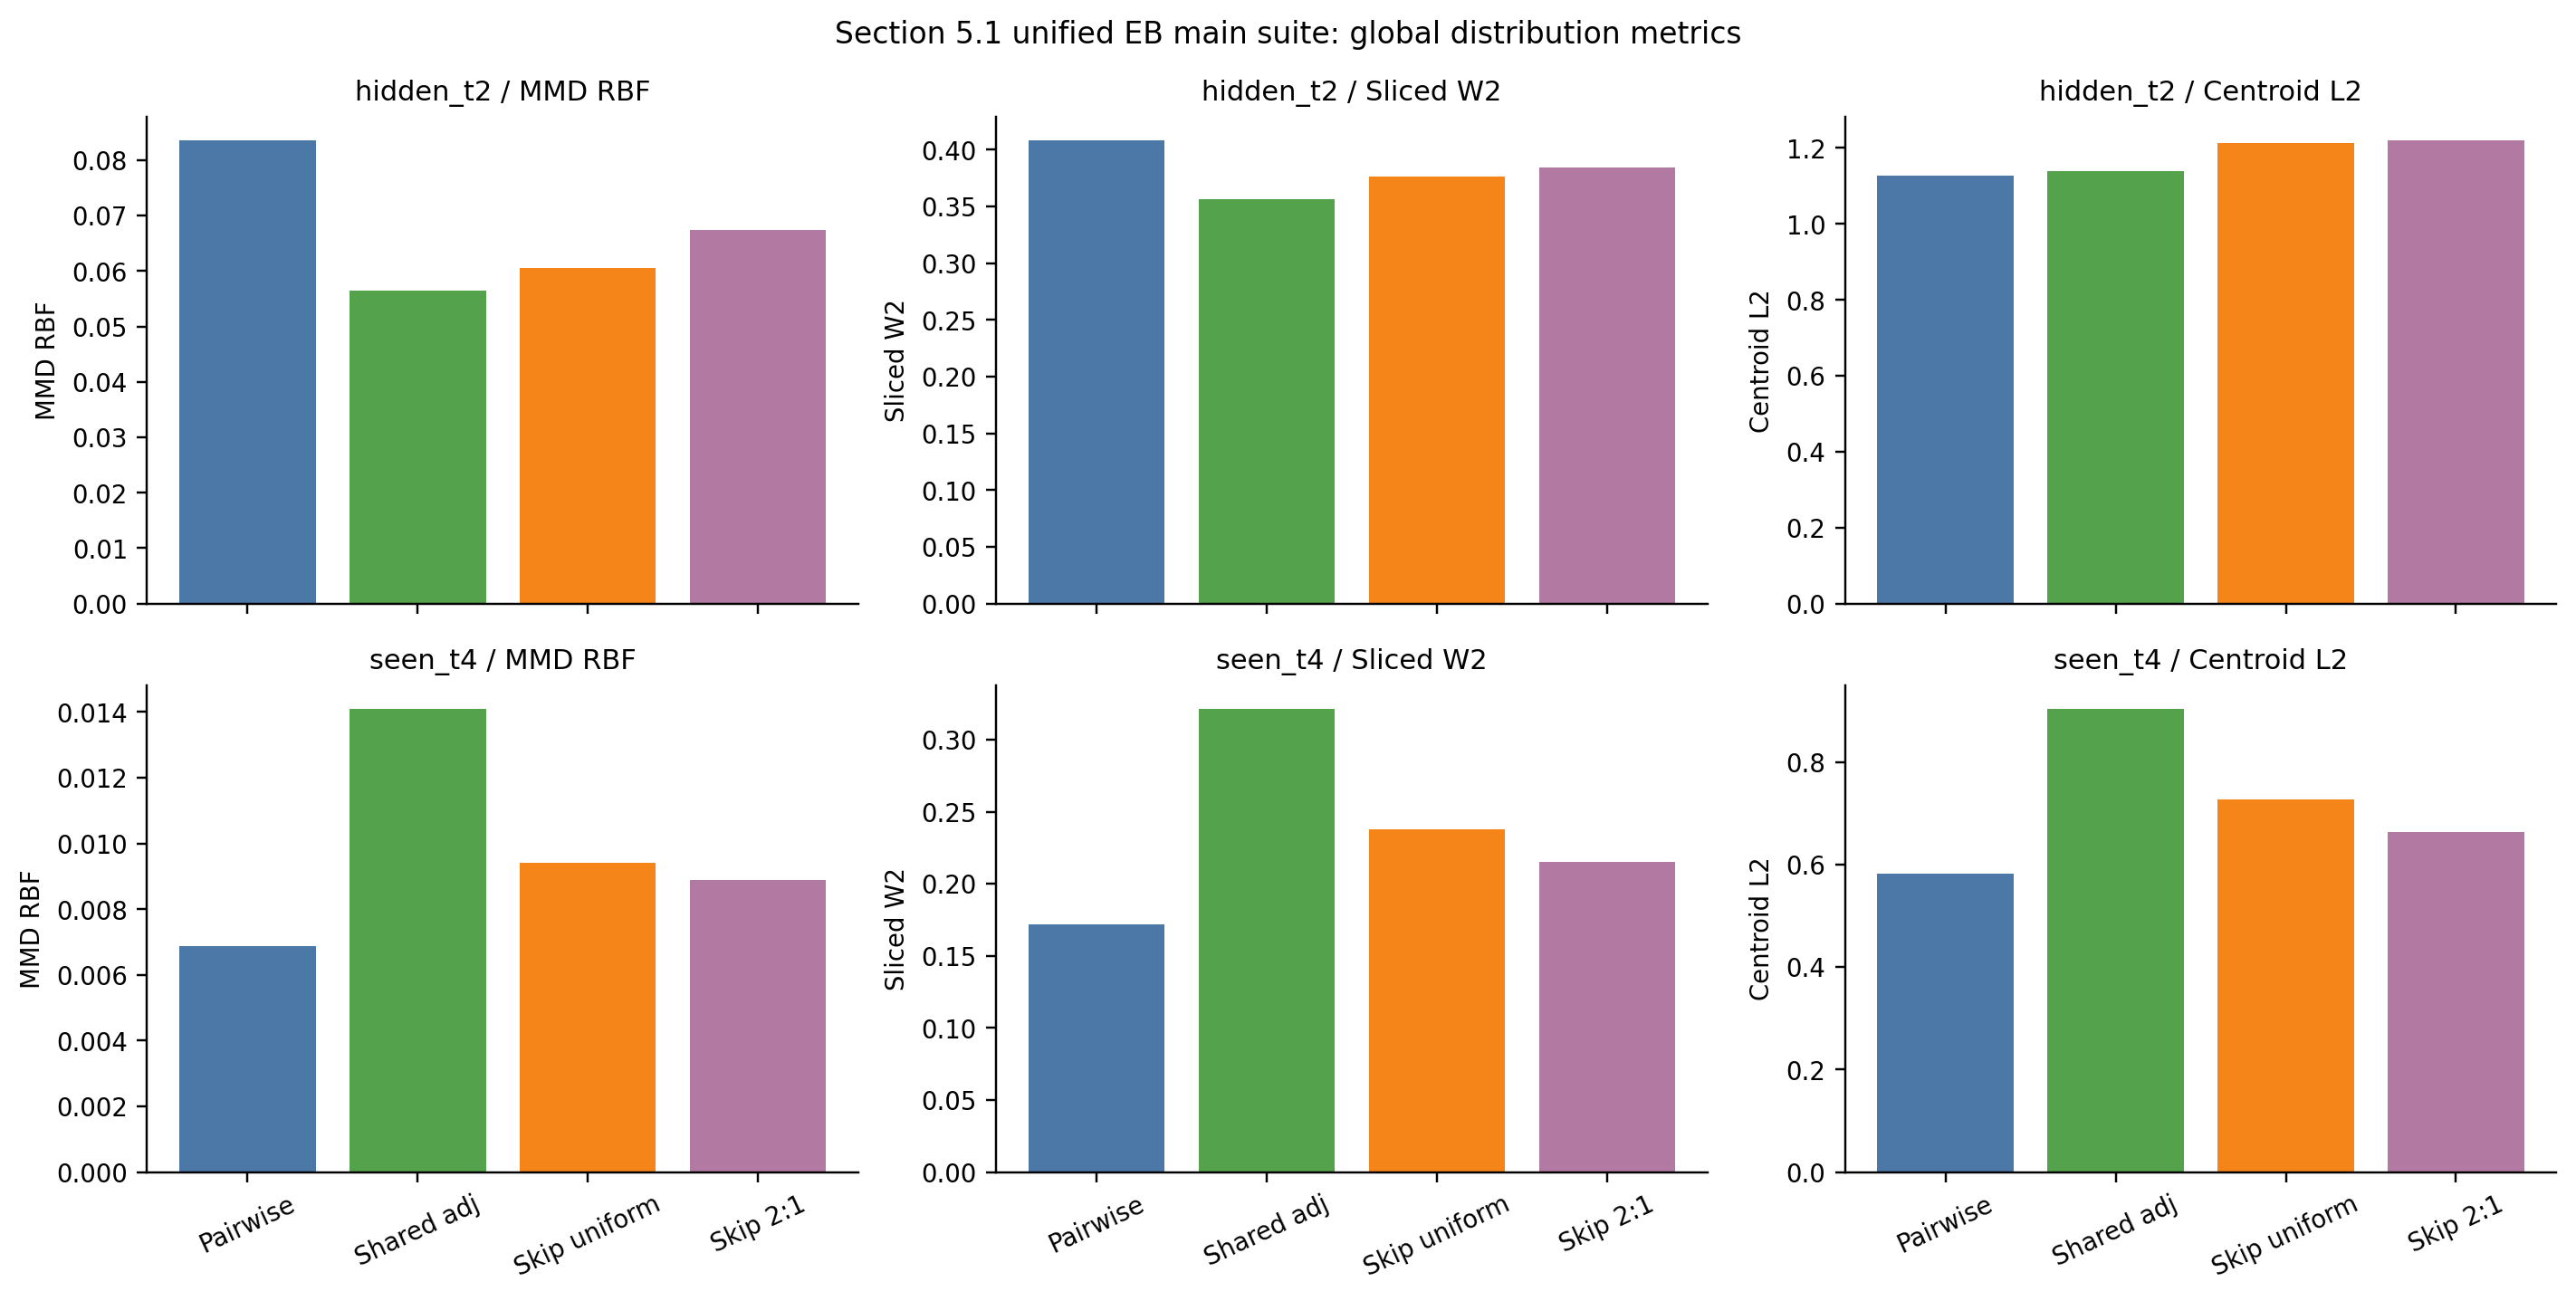

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch05/fig_5_1_main_suite.png')

In [16]:
print("Figure:", figure_path.relative_to(PROJECT_ROOT))
display_png(figure_path)


## 13. Inspect the run summary

The run summary records the paper-facing claim boundary and all official artifact paths. This makes the notebook output auditable after execution.


In [17]:
run_summary = json.loads(run_summary_path.read_text())
section_summary = run_summary["section_5_1_main_suite"]
print("Claim boundary:")
print(section_summary["claim_boundary"])
print()
print("Official artifact keys:")
print(json.dumps({k: v for k, v in section_summary.items() if k.endswith("table") or k == "figure"}, indent=2))


Claim boundary:
shared field improves hidden-time recovery; weighted skip supervision improves seen endpoint long-horizon rollout but may degrade hidden-time recovery, so skip is a long-horizon endpoint constraint rather than a uniformly better dynamics model.

Official artifact keys:
{
  "diag_summary_table": "tables/ch05/tab_5_1_main_suite_diag_summary.csv",
  "diag_table": "tables/ch05/tab_5_1_main_suite_diag.csv",
  "figure": "figures/ch05/fig_5_1_main_suite.png",
  "main_text_results_table": "tables/ch05/tab_5_1_main_text_results.csv",
  "metrics_table": "tables/ch05/tab_5_1_main_suite.csv",
  "summary_table": "tables/ch05/tab_5_1_main_suite_summary.csv"
}


## 14. Final audit

The audit checks that the main-text table has the expected claim parts, excludes cluster-mass side metrics, includes all hand-off rows, preserves exact display values, and that each official artifact exists. This is intentionally last: readers first see the experiment, then see how the paper-facing claims are guarded.


In [18]:
audit = pd.read_csv(main_text_path)
preview_frame(
    audit,
    columns=["claim_part", "method_or_variant", "target_or_boundary", "metric", "display_value"],
    n=28,
)

notebook_source = (PROJECT_ROOT / "notebooks" / "05_1_single_cell_timecourse_main_suite.ipynb").read_text()
audit_section51_main_text_results(audit, notebook_source=notebook_source)
verified_values = verify_expected_display_values(audit)

for path in artifact_paths.values():
    assert path.exists(), path

print("Main-text audit passed")
print("Expected display values verified:", verified_values)
print("Official artifacts verified:", len(artifact_paths))
print(json.dumps(json_ready({k: str(v.relative_to(PROJECT_ROOT)) for k, v in artifact_paths.items()}), indent=2))


,claim_part,method_or_variant,target_or_boundary,metric,display_value
0,hidden_t2_main_comparison,pairwise_local_bridges_6000,hidden_t2,mmd_rbf,0.0836
1,hidden_t2_main_comparison,pairwise_local_bridges_6000,hidden_t2,sliced_w2,0.408
2,hidden_t2_main_comparison,shared_adjacent_only_6000,hidden_t2,mmd_rbf,0.0565
3,hidden_t2_main_comparison,shared_adjacent_only_6000,hidden_t2,sliced_w2,0.356
4,hidden_t2_main_comparison,shared_skip_adj2_skip1_9000,hidden_t2,mmd_rbf,0.0675
5,hidden_t2_main_comparison,shared_skip_adj2_skip1_9000,hidden_t2,sliced_w2,0.384
6,seen_t4_long_horizon,shared_adjacent_only_6000,seen_t4,sliced_w2,0.322
7,seen_t4_long_horizon,shared_adjacent_only_6000,seen_t4,centroid_l2,0.904
8,seen_t4_long_horizon,shared_skip_adj2_skip1_9000,seen_t4,sliced_w2,0.215
9,seen_t4_long_horizon,shared_skip_adj2_skip1_9000,seen_t4,centroid_l2,0.664


Main-text audit passed
Expected display values verified: 24
Official artifacts verified: 7
{
  "metrics": "tables/ch05/tab_5_1_main_suite.csv",
  "summary": "tables/ch05/tab_5_1_main_suite_summary.csv",
  "diagnostics": "tables/ch05/tab_5_1_main_suite_diag.csv",
  "diagnostic_summary": "tables/ch05/tab_5_1_main_suite_diag_summary.csv",
  "main_text": "tables/ch05/tab_5_1_main_text_results.csv",
  "figure": "figures/ch05/fig_5_1_main_suite.png",
  "run_summary": "outputs/ch05/run_summary.json"
}
